<a href="https://colab.research.google.com/github/martaaa-16/244107020205-mobile-course/blob/main/Pertemuan_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. PRAKTIKUM FILTER**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [3]:
def convolution2d(image, kernel, stride, padding):
    pass

In [4]:
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [5]:
# Image Sharpen
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

In [6]:
def convolution2d(image, kernel, stride, padding):
    # 1. Mengambil ukuran citra input dan kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # 2. Menambahkan zero-padding di sekeliling citra masukan
    if padding > 0:
        padded_image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_image = image.copy()

    # 3. Menhitung ukuran dimensi citra keluaran (output)
    output_height = int((image_height - kernel_height + 2 * padding) / stride) + 1
    output_width = int((image_width - kernel_width + 2 * padding) / stride) + 1

    # Matriks penyimpan hasil konvolusi
    output = np.zeros((output_height, output_width), dtype=np.float32)

    # 4. Operasi perkalian dan penjumlahan elemen-demi-elemen (Sliding Window)[cite: 43]
    for y in range(0, output_height):
        for x in range(0, output_width):
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Ekstraksi wilayah piksel tetangga yang ditutupi kernel
            region = padded_image[y_start:y_end, x_start:x_end]

            # Perkalian dan penjumlahan elemen[cite: 43]
            output[y, x] = np.sum(region * kernel)

    # 5. Batasi nilai piksel pada rentang 0-255 dan konversi ke uint8
    output_clipped = np.clip(output, 0, 255).astype(np.uint8)

    # 6. Tampilkan hasil citra secara langsung menggunakan cv2_imshow sesuai standar Colab
    cv2_imshow(output_clipped)

    return output_clipped

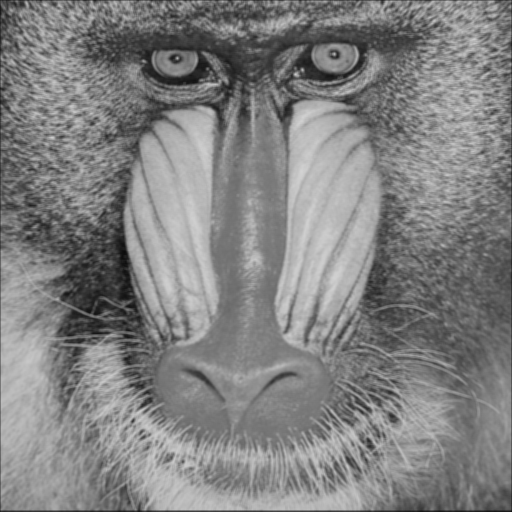

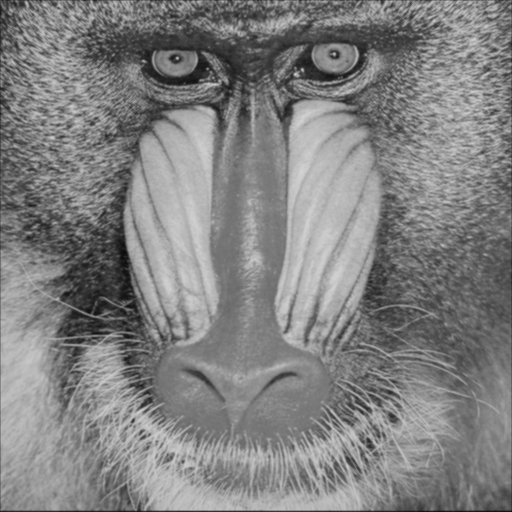

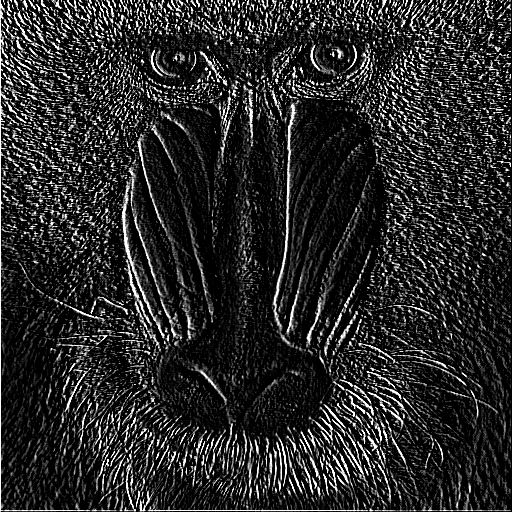

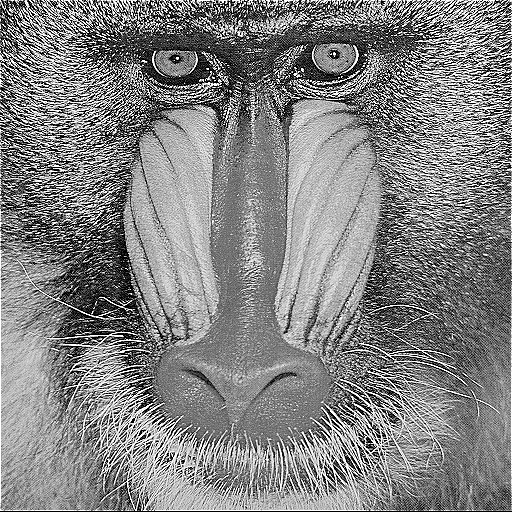

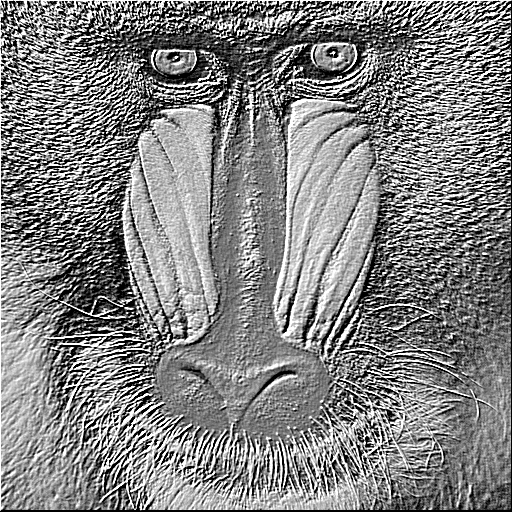

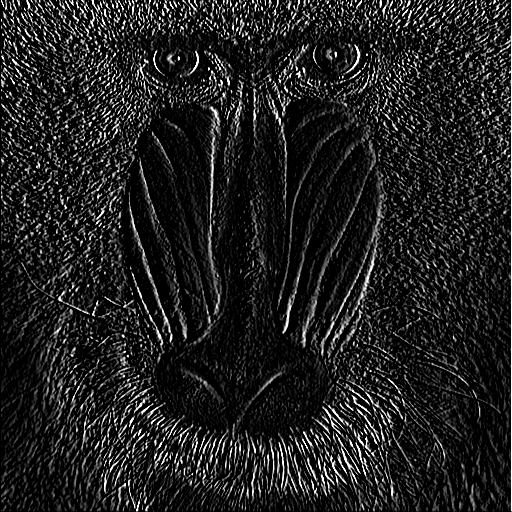

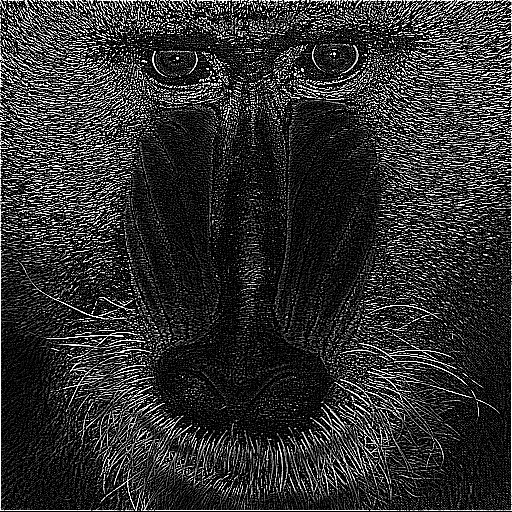

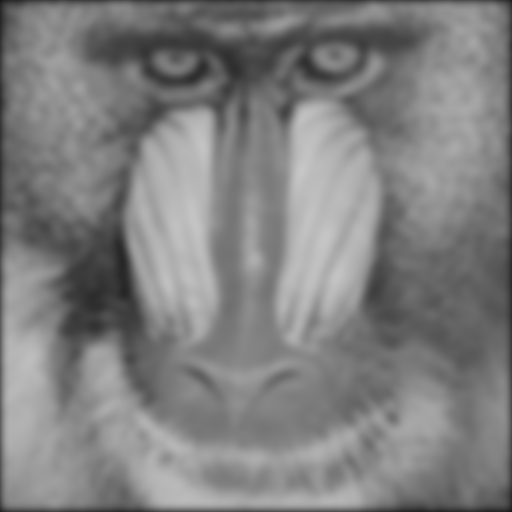

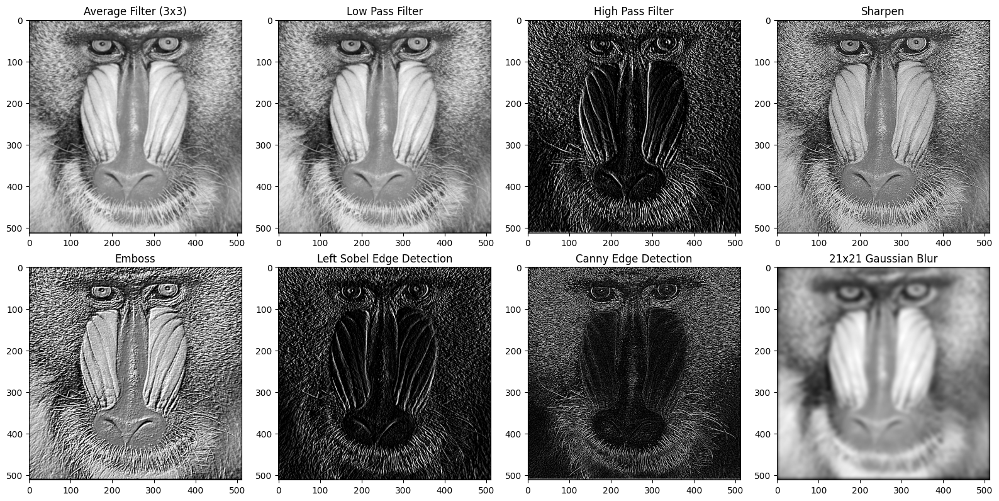

In [7]:
# a. Average Filter (3x3)
kernel_avg = np.ones((3, 3), dtype=np.float32) / 9.0

# b. Low Pass Filter (3x3)
kernel_lpf = np.array([[1, 1, 1],
                       [1, 4, 1],
                       [1, 1, 1]], dtype=np.float32) / 12.0

# c. High Pass Filter (3x3)
kernel_hpf = np.array([[-1,  0, 1],
                       [-1,  0, 3],
                       [-3,  0, 1]], dtype=np.float32)

# d. Sharpen
kernel_sharpen = np.array([[0, -1, 0],
                          [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)

# e. Emboss
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                           [0, 1, 2]], dtype=np.float32)


# f. Left Sobel Edge Detection
kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]], dtype=np.float32)

# g. Canny / Laplacian Edge Detection (-1 di sekeliling, 8 di pusat)
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]], dtype=np.float32)

# h. 21x21 Gaussian Blur Generator
k_size = 21
sigma = math.sqrt(k_size)
gaussian_kernel = cv.getGaussianKernel(k_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Menerapkan fungsi konvolusi milikmu ke setiap kernel
res_avg      = convolution2d(img_gray, kernel_avg, stride=1, padding=1)
res_lpf      = convolution2d(img_gray, kernel_lpf, stride=1, padding=1)
res_hpf      = convolution2d(img_gray, kernel_hpf, stride=1, padding=1)
res_sharpen  = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss   = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_sobel    = convolution2d(img_gray, kernel_sobel_left, stride=1, padding=1)
res_canny    = convolution2d(img_gray, kernel_canny, stride=1, padding=1)
res_gauss21  = convolution2d(img_gray, gauss_kernel, stride=1, padding=10)

# Menampilkan seluruh hasil filter secara berdampingan
plt.figure(figsize=(16, 8))

filters = [
    ("Average Filter (3x3)", res_avg),
    ("Low Pass Filter", res_lpf),
    ("High Pass Filter", res_hpf),
    ("Sharpen", res_sharpen),
    ("Emboss", res_emboss),
    ("Left Sobel Edge Detection", res_sobel),
    ("Canny Edge Detection", res_canny),
    ("21x21 Gaussian Blur", res_gauss21)
]

for idx, (title, res_img) in enumerate(filters, 1):
    plt.subplot(2, 4, idx)
    plt.imshow(res_img, cmap='gray')
    plt.title(title)

plt.tight_layout()
plt.show()

# **E. FILTER LIBRARY DAN FILTER MODERN**

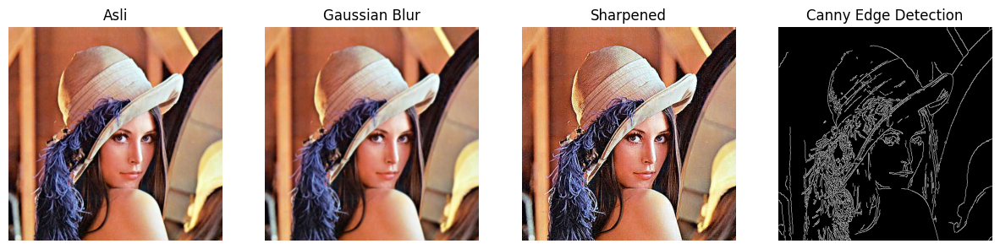

In [18]:
# PERCOBAAN 1

# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

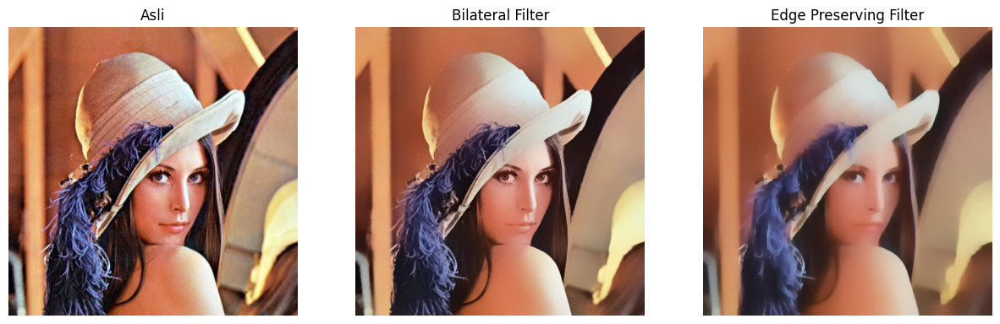

In [9]:
# PERCOBAAN 2

# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bileteral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bileteral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

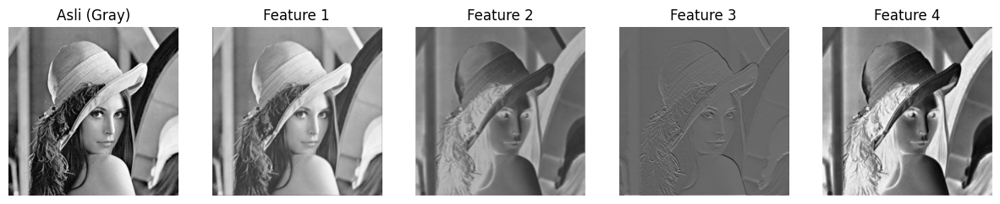

In [20]:
# PERCOBAAN 3

# Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

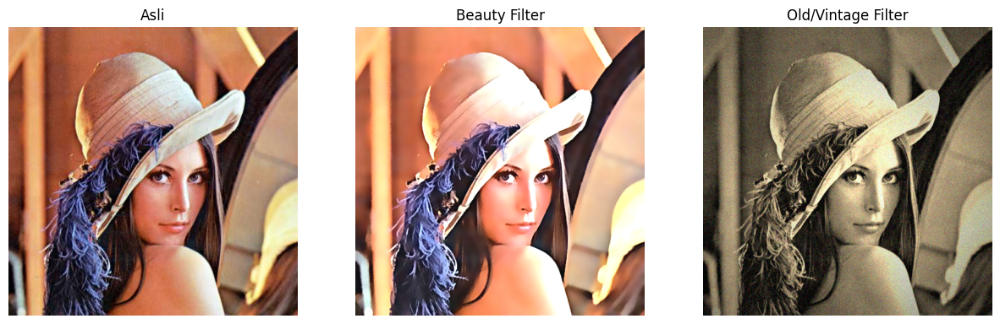

In [11]:
#PERCOBAAN 4

# ===================
# 1. Beauty Filter
# ===================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ===================
# 2. Old/Vintage Filter
# ===================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

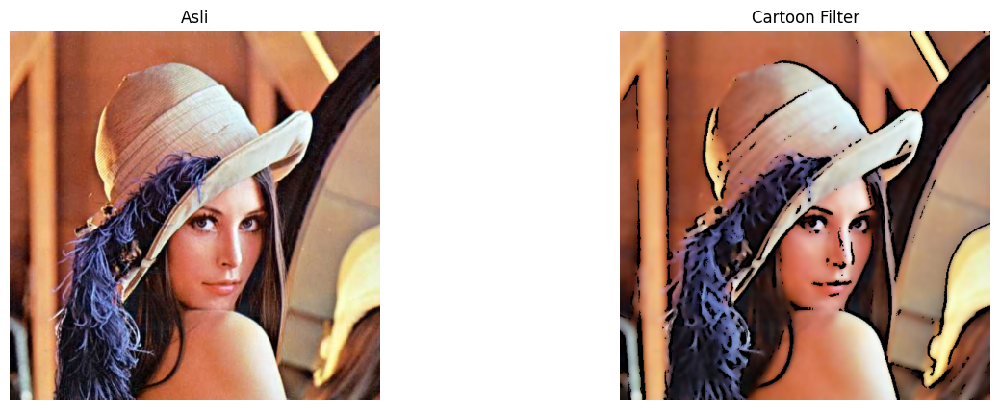

In [12]:
# PERCOBAAN 5

# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

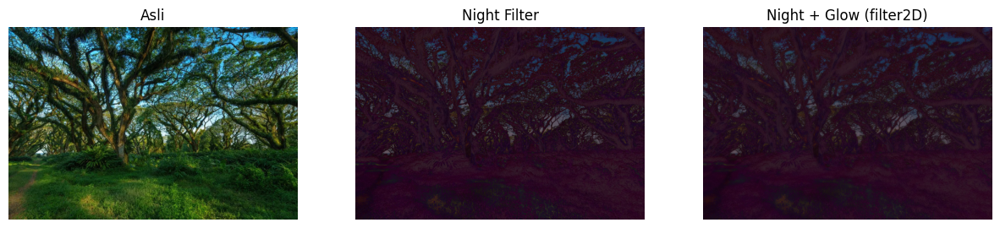

In [13]:
# PERCOBAAN 6

#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

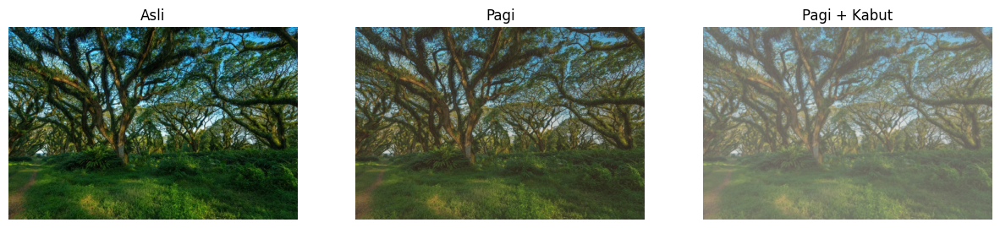

In [14]:
# PERCOBAAN 7

#Filter Suasana pagi dan Kabut
# ===================
# Step 1: Kurangi kontras & cerahkan
# ===================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ===================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ===================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ===================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ===================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

# **Tugas Praktikum Filter Spasial**

1. **Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise "Salt and Pepper"**
* **a.** Tambahkan noise bintik hitam-putih (*Salt and Pepper*) ke sebuah citra keabuan (*grayscale*).
* **b.** Terapkan Mean Filter ($3 \times 3$) dan Median Filter ($3 \times 3$).
* **c.** Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

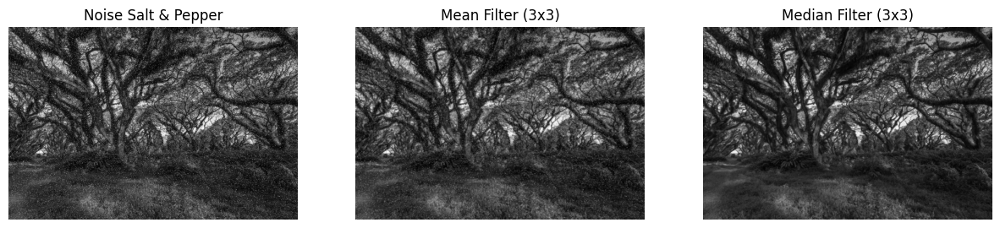

In [15]:
# Jawab Tugas Analisa 1

# Fungsi membuat Salt and Pepper Noise
def add_salt_and_pepper(image, salt_prob=0.02, pepper_prob=0.02):
    noisy = np.copy(image)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

# Generate noise
img_sp_noise = add_salt_and_pepper(img_gray, 0.03, 0.03)

# Terapkan Mean & Median Filter
mean_filtered = cv.blur(img_sp_noise, (3, 3))
median_filtered = cv.medianBlur(img_sp_noise, 3)

show_side_by_side([img_sp_noise, mean_filtered, median_filtered],
                  ["Noise Salt & Pepper", "Mean Filter (3x3)", "Median Filter (3x3)"])

Analisis Visual:
* **Mean Filter:** Bekerja dengan merata-ratakan nilai piksel di sekitarnya. Karena Salt & Pepper bernilai ekstrem ($0$ atau $255$), nilai ekstrem ini ikut terhitung dalam rata-rata sehingga noise menyebar dan menyisa sebagai noda buram (blurry spots).
* **Median Filter:** Bekerja dengan mengurutkan nilai piksel dan mengambil nilai tengah (median). Nilai ekstrem ($0$ atau $255$) otomatis terlempar ke ujung urutan data, sehingga median yang diambil adalah piksel latar belakang yang bersih. Hal ini membuat noise terhapus secara sempurna tanpa mengaburkan detail citra.

2. **Tugas Evaluasi: Pemilihan Ukuran Kernel Terbaik untuk Menajamkan Citra (Sharpening)**
* **a.** Buat kernel penajaman (*Sharpening Kernel*) ukuran $3 \times 3$ dan $5 \times 5$.
* **b.** Terapkan pada citra yang sedikit buram (*blurry*).
* **c.** Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

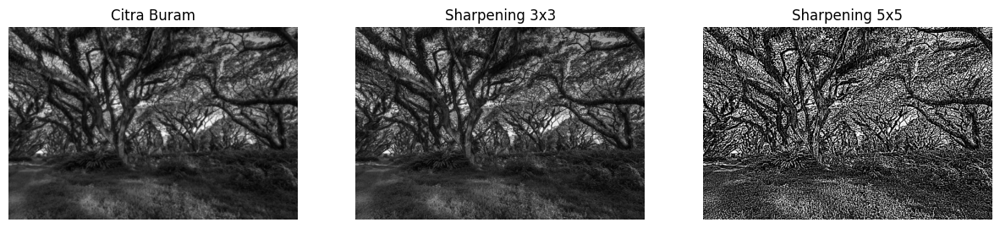

In [16]:
# Jawab Tugas Analisa 2

# Kernel Sharpening 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, 25, -1, -1],
                               [-1, -1, -1, -1, -1],
                               [-1, -1, -1, -1, -1]])

# Terapkan pada gambar buram (blurry)
img_blurry = cv.GaussianBlur(img_gray, (5, 5), 0)
sharp_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
sharp_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

show_side_by_side([img_blurry, sharp_3x3, sharp_5x5],
                  ["Citra Buram", "Sharpening 3x3", "Sharpening 5x5"])

Evaluasi & Kesimpulan:
* **Kernel 3x3:** Menajamkan tepi secara alami tanpa memicu artefak atau noise distortion yang mengganggu.
* **Kernel 5x5:** Terlalu agresif (over-sharpening), memicu timbulnya halo effect (garis terang/gelap buatan di tepi) dan memperbesar bintik noise.
* **Rekomendasi:** Kernel $3 \times 3$ adalah yang paling optimal untuk penggunaan sehari-hari karena menghasilkan ketajaman yang seimbang.

3. **Tugas Kreasi: Filter Kartun Sederhana**
* **a.** Buatlah sebuah fungsi kustom bernama `kartun(image)` yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.
* **b.** Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

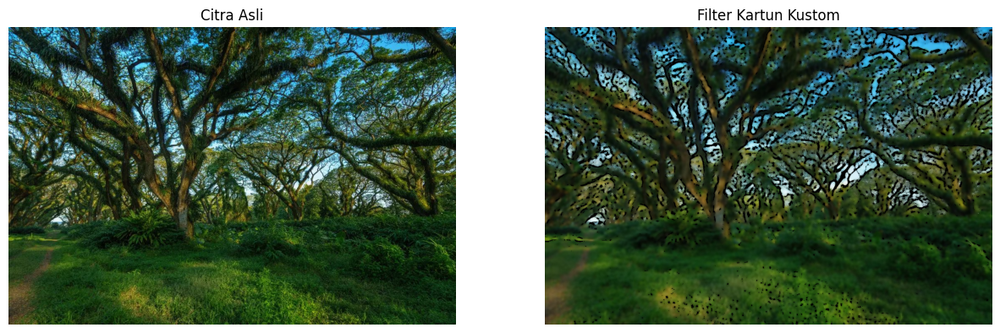

In [17]:
# Jawab Tugas Analisa 3

def kartun(image):
    """
    Fungsi kustom untuk menghasilkan efek kartun sederhana.
    """
    # 1. Konversi ke Grayscale jika input BGR
    if len(image.shape) == 3:
        gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    else:
        gray_img = image.copy()

    # 2. Deteksi Garis Tepi dengan Adaptive Thresholding
    gray_blur = cv.medianBlur(gray_img, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 8)

    # 3. Penghalusan Warna dengan Bilateral Filter
    if len(image.shape) == 3:
        color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)
        # 4. Penggabungan dengan Operasi Bitwise AND
        cartoon_result = cv.bitwise_and(color_smooth, color_smooth, mask=edges)
    else:
        cartoon_result = cv.bitwise_and(gray_img, gray_img, mask=edges)

    return cartoon_result

# Uji Coba Fungsi Kustom Kartun
hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["Citra Asli", "Filter Kartun Kustom"])